# Analysis of uncertainty vs. integrated SNR

This notebook plots the *N-M* percentile range of the 2100 $\theta$ posterior against the cumulative signal to nose ratio (cSNR) in 2100, which I define as

$
  cSNR = \left( \int_{2025}^{2100} \dfrac{g_{t'}}{\bar{f}_{t'}} dt'\right) \sqrt{ \dfrac{75}{\sigma^2_{f_{2\times}} + \sigma^{2}_{\varepsilon}} \dfrac{1 - \rho}{1 + \rho} }
$

# Step 0: Config, dependent functions, and other setup

In [1]:
import os
import gc

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from datatree import open_datatree
from src.presets import get_presets
from scipy.stats import describe
from src.filtering import filter_by_cost_ratio_memeff
from pathlib import Path

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [3]:
# this is new and right (ง'̀-'́)ง
def get_angle(a1, a2, b1, b2, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

def get_stats(x, PLO=5, PHI=95):
    return np.nanmean(x), np.nanmedian(x), np.nanpercentile(x, PHI) - np.percentile(x, PLO)

In [4]:
def get_cumulative_snr(t, e, F2x_avg, F2x_std, noise_var, auto_corr):
    co2 = F2x_avg * np.log(e.conc['CO2'][t] / e.conc["CO2"][0])
    geo = np.abs(e.forcing['geo'][t])

    upper = np.cumsum(geo / co2)[-1]

    param_piece = (F2x_std**2 / 75.) * np.mean(
        (np.abs(e.forcing['geo'][1:t])) / (F2x_avg * np.log(e.conc['CO2'][1:t] / e.conc["CO2"][0]))**2
    )**2

    int_var_piece = (noise_var / 75.) * ((1 + auto_corr) / (1 - auto_corr))

    denom = np.sqrt(param_piece + int_var_piece)

    snr = upper / denom
    # snr *= correction

    #lower = [(np.cumsum((F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])))**2 
    #+ samp_std**2 * t * ((1 + auto_corr) / (1 - auto_corr))
    #)[-1] for (f, l, g, ep) in zip(fs, ls, gs, es)]
    #+ (samp_std / np.sqrt(1 - auto_corr**2)) * np.cumsum(
    #    (f * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]) / (l + g * ep) )))[-1] for (f, l, g, ep) in zip(fs, ls, gs, es)]
    #lower = np.mean(lower)

    # print(upper, lower)

    return snr

# Step 1: Import data, filter, make angle lists, and dispose

In [5]:
from src.emis import EmissionsBaseline

In [6]:
# simulation config
cwd = os.getcwd()

# file attributes we need to import
ssps = ['ssp245', 'ssp585']
DEGpDECs = ['0.1', '0.2']
noise_models = ['Noiseless', 'AR(0)', 'AR(1)']
anglesf = ['9', '12', '14', '17', '21', '33']

# static simulation attributes 
TMIN = 2025
ECS = 3.0  # NOTE: EVENTUALLY I'LL DO THIS FOR MULTIPLE ECS VALUES
F2x_avg = 4.58
NYRSRAMP = 50
Nwinds = '14custom'
Nens = 500

INT_VAR_STD = 0.27**2  # from proistosescu and huybers
AUTO_CORR = 0.2  # AR(1) param

# dictionary of noise model characteristics
noise_model_chars = {
    'Noiseless': {
        INT_VAR_STD: 0,
        AUTO_CORR: 0
    },
    'AR(0)': {
        INT_VAR_STD: 0.27**2,
        AUTO_CORR: 0
    },
    'AR(1)': {
        INT_VAR_STD: 0.27**2,
        AUTO_CORR: 0.2
    }
}

In [8]:
dt_meta = open_datatree(
    f'{cwd}/../../data/output/pco2geowc/margobs_ws_ssp245_pco2geowc_TMIN2025_AR1_THETA14_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc',
    engine='netcdf4')

In [9]:
relevant_vars = ['cost_hist', 'controls', 'controls_hist']
all_vars = [x for x in dt_meta['2027'].ds.data_vars]
dropped_vars = [v for v in all_vars if v not in relevant_vars]
THRESHOLD = 1e-2  # cost function ratio filtering

# cleanup
for node in dt_meta.subtree:
    if node.ds is not None:
        node.ds.close()

del dt_meta
gc.collect()

2663

In [10]:
data_dir_root = f'{cwd}/../../data/output/'
simulation_dict = {}

wind_ = '2100'
PLO = 5  # lower percentile for percentile range
PHI = 95  # higher percentile for percentile range

for ssp in ssps:
    print(f"🏭 Processing {ssp}...")
    simulation_dict[ssp] = {}
    for DEGpDEC in DEGpDECs:
        print(f"    📐 Processing DEGpDEC {DEGpDEC}...")
        simulation_dict[ssp][DEGpDEC] = {}

        # make emissions baseline
        e = EmissionsBaseline(ssp, TMIN, 2100,
                              geo=True, DEG_PER_DEC=float(DEGpDEC),
                              LAMBDA=4.58 * np.log(2) / ECS, GAMMA=0.7, EPSILON=1.58, F_EFF_GEO=0.09,
                              T_START=TMIN, T_END=TMIN + NYRSRAMP)
        
        for noise_model in noise_models:
            print(f"        🔊 Processing noise model {noise_model}...")
            simulation_dict[ssp][DEGpDEC][noise_model] = {}
            if noise_model == 'Noiseless':
                prefix = 'margobs_ws_nonoise'
                model = 'pco2geowc_nn'

            else:
                prefix = 'margobs_ws'
                model = 'pco2geowc'

            for angles in anglesf:
                print(f"            📐 Processing angle = {angles}...")
                simulation_dict[ssp][DEGpDEC][noise_model][angles] = {}

                if noise_model == 'AR(0)':
                    filename = f'{data_dir_root}/{model}/{prefix}_{ssp}_{model}_TMIN{TMIN}_AR0_THETA{angles}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nwinds{Nwinds}_Nens{Nens}.nc'

                elif noise_model == 'AR(1)':
                    filename = f'{data_dir_root}/{model}/{prefix}_{ssp}_{model}_TMIN{TMIN}_AR1_THETA{angles}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nwinds{Nwinds}_Nens{Nens}.nc'
                
                else:  # no noise
                    filename = f'{data_dir_root}/{model}/{prefix}_{ssp}_{model}_TMIN{TMIN}_THETA{angles}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nwinds{Nwinds}_Nens{Nens}.nc'

                dt = open_datatree(filename, engine='netcdf4', drop_variables=dropped_vars)

                ds = filter_by_cost_ratio_memeff(dt[wind_].ds, threshold=THRESHOLD)

                # compute prior uncertainty 
                prior_a1 = ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
                prior_b1 = ds.controls_hist.sel(vari='BETA_R1', iter=0).values
                prior_a2 = ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
                prior_b2 = ds.controls_hist.sel(vari='BETA_R2', iter=0).values
                prior_l = ds.controls_hist.sel(vari='L', iter=0).values
                prior_g = ds.controls_hist.sel(vari='G', iter=0).values
                prior_eps = ds.controls_hist.sel(vari='EPS', iter=0).values

                angles_prior = np.zeros(Nens)
                for i in range(Nens):
                    angles_prior[i] = get_angle(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])
                print(f"                ✅ Prior angles computed!")

                simulation_dict[ssp][DEGpDEC][noise_model][angles]['prior'] = angles_prior
                simulation_dict[ssp][DEGpDEC][noise_model][angles][f'prior_{PLO}-{PHI}_range'] = np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)

                # compute posterior uncertainty 
                tmp_a1 = ds.controls.sel(vari='ALPHA_R1').values
                tmp_a2 = ds.controls.sel(vari='ALPHA_R2').values
                tmp_b1 = ds.controls.sel(vari='BETA_R1').values
                tmp_b2 = ds.controls.sel(vari='BETA_R2').values
                tmp_l = ds.controls.sel(vari='L').values
                tmp_g = ds.controls.sel(vari='G').values
                tmp_eps = ds.controls.sel(vari='EPS').values

                angles_post = np.zeros(Nens)
                for i in range(Nens):
                    angles_post[i] = get_angle(tmp_a1[i], tmp_a2[i], tmp_b1[i], tmp_b2[i], tmp_l[i], tmp_eps[i], tmp_g[i])
                print(f"                ✅ Posterior angles computed!")

                simulation_dict[ssp][DEGpDEC][noise_model][angles]['post'] = angles_post
                simulation_dict[ssp][DEGpDEC][noise_model][angles][f'post_{PLO}-{PHI}_range'] = np.nanpercentile(angles_post, PHI) - np.nanpercentile(angles_post, PLO)

                # compute cumulative SNR
                cSNR = get_cumulative_snr(2100 - int(TMIN), e,
                                            F2x_avg,
                                            0.519,
                                            noise_model_chars[noise_model][INT_VAR_STD],
                                            noise_model_chars[noise_model][AUTO_CORR])                    

                simulation_dict[ssp][DEGpDEC][noise_model][angles]['cSNR'] = cSNR

                # cleanup
                for node in dt.subtree:
                    if node.ds is not None:
                        node.ds.close()

                del dt
                gc.collect()
                print(f"                🚮 Trash taken out, restarting process...")


🏭 Processing ssp245...
    📐 Processing DEGpDEC 0.1...
        🔊 Processing noise model Noiseless...
            📐 Processing angle = 9...
                ✅ Prior angles computed!
                ✅ Posterior angles computed!
                🚮 Trash taken out, restarting process...
            📐 Processing angle = 12...
                ✅ Prior angles computed!
                ✅ Posterior angles computed!
                🚮 Trash taken out, restarting process...
            📐 Processing angle = 14...
                ✅ Prior angles computed!
                ✅ Posterior angles computed!
                🚮 Trash taken out, restarting process...
            📐 Processing angle = 17...
                ✅ Prior angles computed!
                ✅ Posterior angles computed!
                🚮 Trash taken out, restarting process...
            📐 Processing angle = 21...
                ✅ Prior angles computed!
                ✅ Posterior angles computed!
                🚮 Trash taken out, restarting p

In [11]:
simulation_dict

{'ssp245': {'0.1': {'Noiseless': {'9': {'prior': array([14.20157635, 19.53725338, 14.53870909, 17.21802494, 16.98653318,
            11.2631371 , 19.78324392, 19.90960667, 16.30784288, 14.84119156,
            12.16029389,  7.59795685, 17.9654362 ,  4.6474064 ,  5.67975972,
            12.54745552, 13.99338711, 14.03531031, 13.5257193 ,  6.46927666,
            15.02066053, 12.30270146,  9.68015695, 12.79661174, 12.39116039,
            15.50398269, 12.52496537, 17.15011262, 11.27071164, 16.83340959,
            11.46122281, 12.87893085, 12.82666392, 12.0418863 ,  9.44915655,
            20.7147826 , 11.6705217 , 18.81185641, 12.62266653, 14.47672243,
            12.6468798 ,  3.44626934, 10.07154857, 10.10285541,  6.7337718 ,
            13.55963429, 12.88054244, 12.25476759, 15.05771278,  8.85555895,
            13.3341886 , 26.73937472, 17.87471058, 18.98855705, 19.19409014,
            10.56847643, 16.80227149, 14.53477734, 17.86988017, 11.20904743,
            14.94064473, 11.0547

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/sims/figs/2026-3-4-unc_vs_csnr.png!


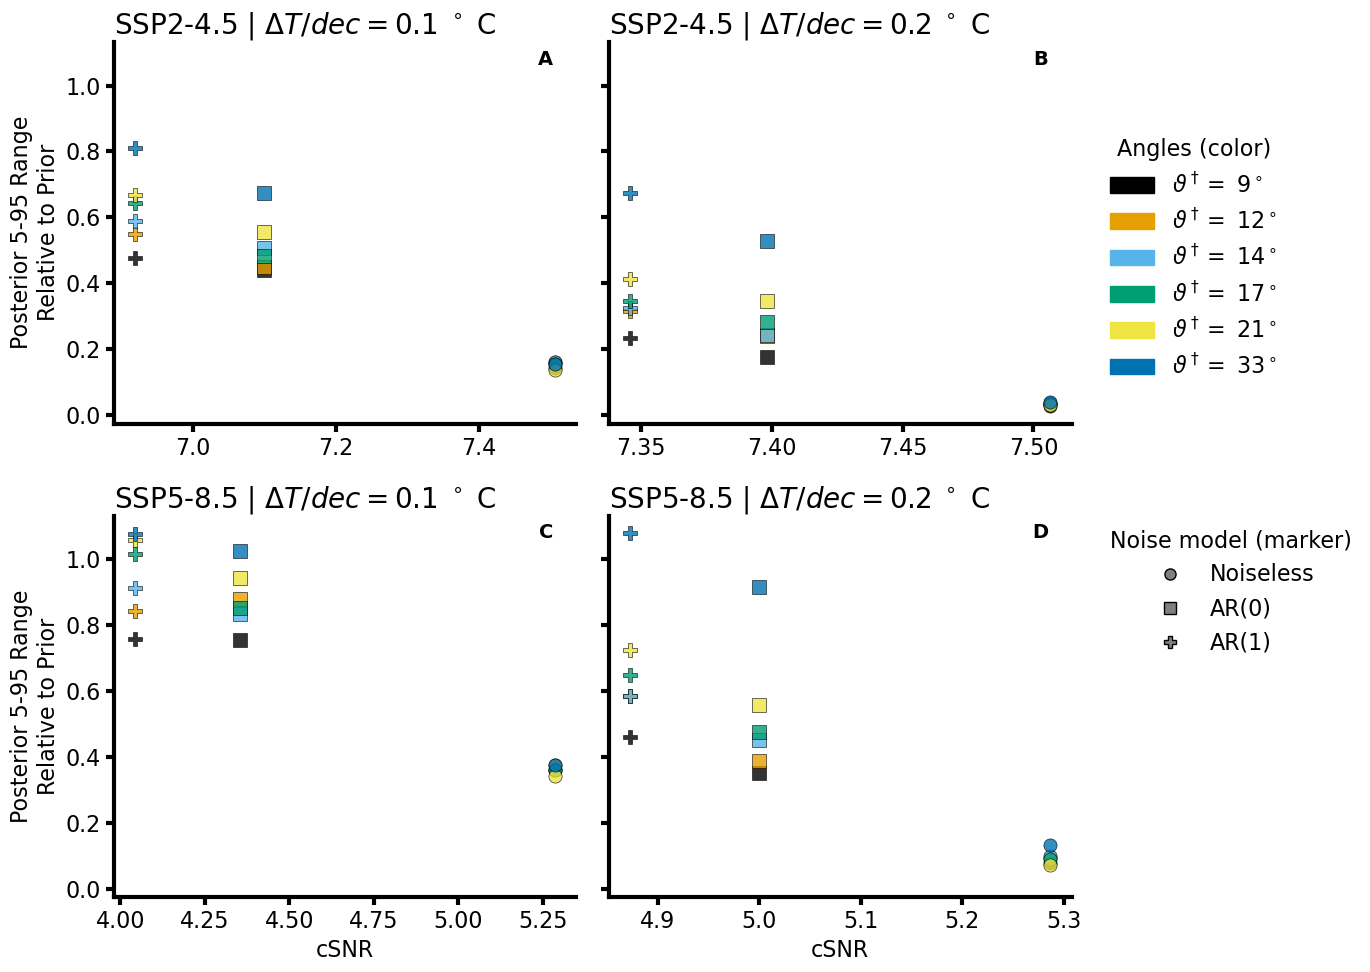

In [21]:
import numpy as np
# Plot ratio of posterior/prior 5-95 percentile range vs cSNR
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# prepare color and marker lists from presets (keeps notebook's styling)
plot_presets, _ = get_presets(markers=True)
prop_cycle = plot_presets['axes.prop_cycle']
by_key = prop_cycle.by_key()
colors = by_key.get('color', [])
markers = by_key.get('marker', [])
angles_list = anglesf  # ['9','12','14','17','21','33'] from above
noise_list = noise_models  # ['no_noise','AR(0)','AR(1)']

# mapping from angle string to color (cycle if needed)
angle_to_color = {a: colors[i % len(colors)] for i, a in enumerate(angles_list)}
# mapping noise model to marker (cycle if needed)
noise_to_marker = {n: markers[i % len(markers)] for i, n in enumerate(noise_list)}

# create 2x2 grid: rows by ssp, cols by DEGpDEC (or vice versa)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=True)
axs = axs.reshape(2, 2)
ssp_order = ssps  # ['ssp245','ssp585']
deg_order = DEGpDECs  # ['0.1','0.2']
ssp_titles = ['SSP2-4.5', 'SSP5-8.5']

for i_ssp, ssp in enumerate(ssp_order):
    for j_deg, deg in enumerate(deg_order):
        ax = axs[i_ssp, j_deg]
        ax.set_title(f'{ssp_titles[i_ssp]} | $\Delta T / dec = ${deg} $^\circ$ C')
        if i_ssp == 1:
            ax.set_xlabel('cSNR')
        if j_deg == 0:
            ax.set_ylabel('Posterior 5-95 Range\nRelative to Prior')

        # collect plotted points for legend handles
        for noise in noise_list:
            # some angle/noise combinations may be missing (e.g., 33 with AR(0))
            for ang in angles_list:
                try:
                    prior_range = simulation_dict[ssp][deg][noise][ang][f'prior_{PLO}-{PHI}_range']
                    post_range = simulation_dict[ssp][deg][noise][ang][f'post_{PLO}-{PHI}_range']
                    csnr = simulation_dict[ssp][deg][noise][ang]['cSNR']
                except Exception:
                    continue

                # guard against zero or nan prior range
                if prior_range == 0 or np.isnan(prior_range):
                    ratio = np.nan
                else:
                    ratio = post_range / prior_range

                ax.scatter(csnr, ratio, color=angle_to_color[ang], marker=noise_to_marker[noise], s=90, edgecolors='k', linewidths=0.5, alpha=0.8)

# build legend: angles (colors) and noise models (markers)
angle_handles = [mpatches.Patch(color=angle_to_color[a], label=r'$\vartheta^\dagger =$ {}$^\circ$'.format(a)) for a in angles_list]
noise_handles = [Line2D([0], [0], marker=noise_to_marker[n], color='w', label=n, markerfacecolor='gray', markersize=8, markeredgecolor='k') for n in noise_list]

#for ax in axs.flatten():
#    ax.set_ylim((0, 1))

# place legends outside the axes to avoid overlap
axs[0,1].legend(handles=angle_handles, title='Angles (color)', bbox_to_anchor=(1.04, 0.8), loc='upper left')
axs[1,1].legend(handles=noise_handles, title='Noise model (marker)', bbox_to_anchor=(1.04, 0.8), loc='center left')

labels = ['A','B','C','D']
for i, ax in enumerate(np.array(axs).flatten()):
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

if SAVE_FIGS:
    plt.savefig(basefile + 'unc_vs_csnr.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {basefile + 'unc_vs_csnr.png'}!")

plt.tight_layout()
plt.show()

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/sims/figs/2026-3-4-unc_vs_csnr_scattered.png!


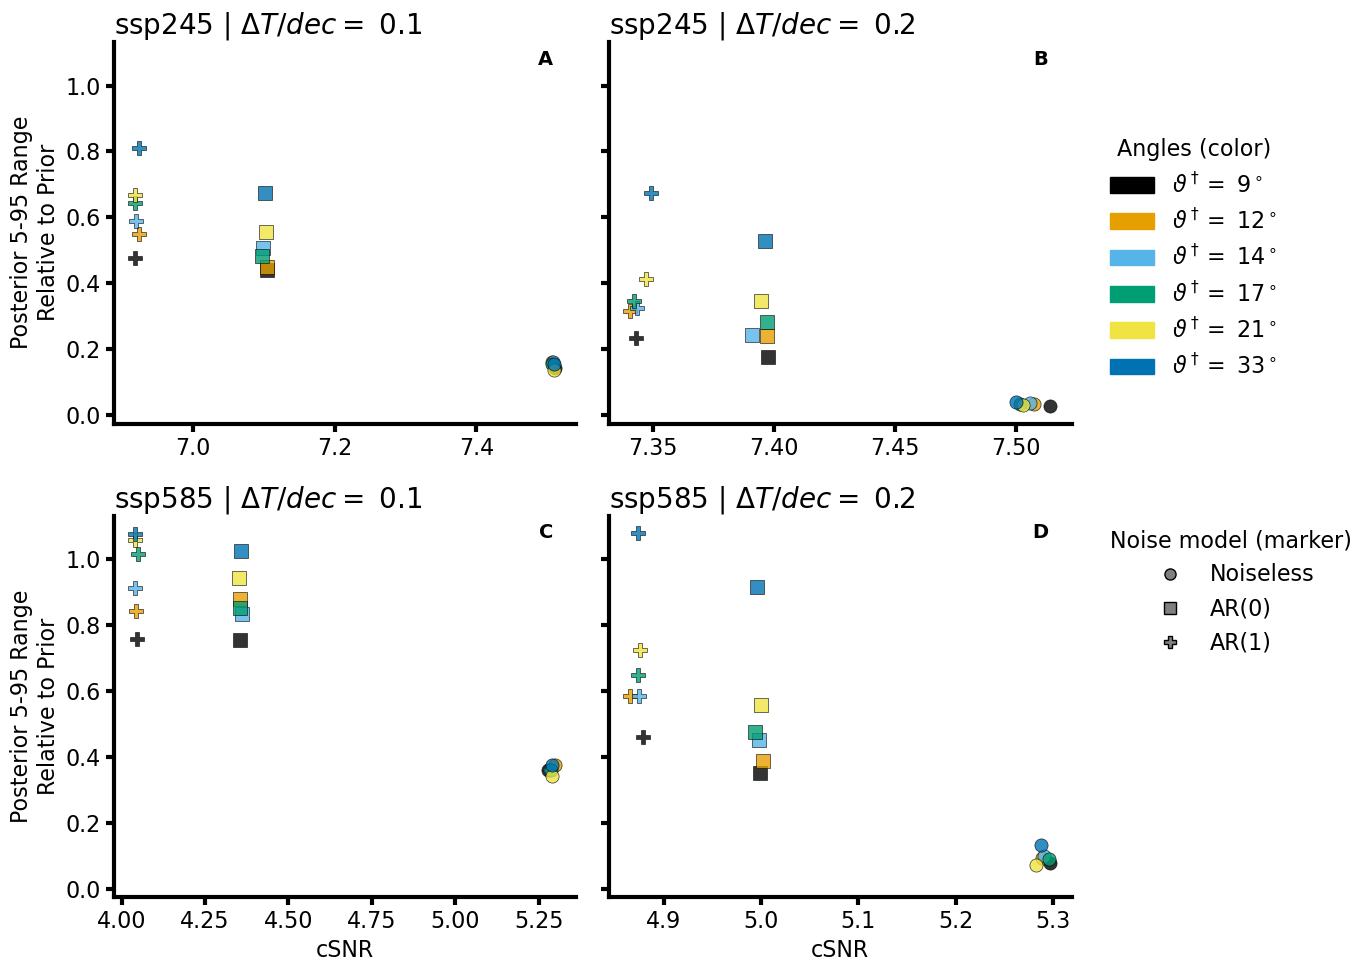

In [13]:
import numpy as np
# Plot ratio of posterior/prior 5-95 percentile range vs cSNR
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# prepare color and marker lists from presets (keeps notebook's styling)
plot_presets, _ = get_presets(markers=True)
prop_cycle = plot_presets['axes.prop_cycle']
by_key = prop_cycle.by_key()
colors = by_key.get('color', [])
markers = by_key.get('marker', [])
angles_list = anglesf  # ['9','12','14','17','21','33'] from above
noise_list = noise_models  # ['no_noise','AR(0)','AR(1)']

# mapping from angle string to color (cycle if needed)
angle_to_color = {a: colors[i % len(colors)] for i, a in enumerate(angles_list)}
# mapping noise model to marker (cycle if needed)
noise_to_marker = {n: markers[i % len(markers)] for i, n in enumerate(noise_list)}

# create 2x2 grid: rows by ssp, cols by DEGpDEC (or vice versa)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=True)
axs = axs.reshape(2, 2)
ssp_order = ssps  # ['ssp245','ssp585']
deg_order = DEGpDECs  # ['0.1','0.2']

for i_ssp, ssp in enumerate(ssp_order):
    for j_deg, deg in enumerate(deg_order):
        ax = axs[i_ssp, j_deg]
        ax.set_title(f'{ssp} | $\Delta T / dec = $ {deg}')
        if i_ssp == 1:
            ax.set_xlabel('cSNR')
        if j_deg == 0:
            ax.set_ylabel('Posterior 5-95 Range\nRelative to Prior')

        # collect plotted points for legend handles
        for noise in noise_list:
            # some angle/noise combinations may be missing (e.g., 33 with AR(0))
            for ang in angles_list:
                try:
                    prior_range = simulation_dict[ssp][deg][noise][ang][f'prior_{PLO}-{PHI}_range']
                    post_range = simulation_dict[ssp][deg][noise][ang][f'post_{PLO}-{PHI}_range']
                    csnr = simulation_dict[ssp][deg][noise][ang]['cSNR']
                except Exception:
                    continue

                # guard against zero or nan prior range
                if prior_range == 0 or np.isnan(prior_range):
                    ratio = np.nan
                else:
                    ratio = post_range / prior_range

                ax.scatter(csnr + np.random.normal(0, 0.005), ratio, color=angle_to_color[ang], marker=noise_to_marker[noise], s=90, edgecolors='k', linewidths=0.5, alpha=0.8)

# build legend: angles (colors) and noise models (markers)
angle_handles = [mpatches.Patch(color=angle_to_color[a], label=r'$\vartheta^\dagger =$ {}$^\circ$'.format(a)) for a in angles_list]
noise_handles = [Line2D([0], [0], marker=noise_to_marker[n], color='w', label=n, markerfacecolor='gray', markersize=8, markeredgecolor='k') for n in noise_list]

#for ax in axs.flatten():
#    ax.set_ylim((0, 1))

# place legends outside the axes to avoid overlap
axs[0,1].legend(handles=angle_handles, title='Angles (color)', bbox_to_anchor=(1.04, 0.8), loc='upper left')
axs[1,1].legend(handles=noise_handles, title='Noise model (marker)', bbox_to_anchor=(1.04, 0.8), loc='center left')


labels = ['A','B','C','D']
for i, ax in enumerate(np.array(axs).flatten()):
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
    
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(basefile + 'unc_vs_csnr_scattered.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {basefile + 'unc_vs_csnr_scattered.png'}!")
plt.show()

In [ ]:
L = 1.06
F2x = 4.58
G = 0.7
EPS = 1.58

# noise attributes 
auto_corr = 0.2
noise_var = 0.27

# make emissions pathways of interest
e_ssp2_lo = EmissionsBaseline('ssp245', 2020, 2100, True, 0.1, L, G, EPS, 0.09, 2025, 2075)
e_ssp2_hi = EmissionsBaseline('ssp245', 2020, 2100, True, 0.2, L, G, EPS, 0.09, 2025, 2075)
e_ssp5_lo = EmissionsBaseline('ssp585', 2020, 2100, True, 0.1, L, G, EPS, 0.09, 2025, 2075)
e_ssp5_hi = EmissionsBaseline('ssp585', 2020, 2100, True, 0.2, L, G, EPS, 0.09, 2025, 2075)

In [ ]:
e = e_ssp2_lo

In [ ]:
t = 75
co2 = 4.58 * np.log(e.conc['CO2'][t] / e.conc["CO2"][0])
geo = np.abs(e.forcing['geo'][t])

upper = np.cumsum(geo / co2)[-1]

param_piece = (0.519**2 / 75.) * np.mean(
    (np.abs(e.forcing['geo'][1:t]))**2 / (F2x_avg * np.log(e.conc['CO2'][1:t] / e.conc["CO2"][0]))**4
)

print(F2x_avg * np.log(e.conc['CO2'][:t] / e.conc["CO2"][0]))

int_var_piece = (noise_var / 75.) * ((1 + auto_corr) / (1 - auto_corr))

In [ ]:
# compute co2 forcing
f_co2_ssp2_lo = F2x * np.log(e_ssp2_lo.conc['CO2'] / 278.3)
f_co2_ssp2_hi = F2x * np.log(e_ssp2_hi.conc['CO2'] / 278.3)
f_co2_ssp5_lo = F2x * np.log(e_ssp5_lo.conc['CO2'] / 278.3)
f_co2_ssp5_hi = F2x * np.log(e_ssp5_hi.conc['CO2'] / 278.3)

In [ ]:
times = np.arange(0, len(f_co2_ssp2_lo)-1, 1)

# set random variables
np.random.seed(48)
ar0_noise_ts = np.random.normal(0, noise_var, size=(len(times)))
ar1_noise_ts = np.zeros_like(times, dtype=float)
ar1_noise_ts[0] = np.random.normal(0, noise_var)  # set initial condition of ar(1) time series

for t in range(1, len(times)):
    ar1_noise_ts[t] = auto_corr * ar1_noise_ts[t-1] + np.random.normal(0, noise_var)

# check plots
plt.plot(times, ar0_noise_ts, label='ar(0)')
plt.plot(times, ar1_noise_ts, label='ar(1)')
plt.legend()
plt.show()

In [ ]:
# empty arrays for SNRs
timess = np.arange(0, 70, 1)
snr_nn_ssp2_lo = np.zeros_like(timess, dtype=float)
snr_ar0_ssp2_lo = np.zeros_like(timess, dtype=float)
snr_ar1_ssp2_lo = np.zeros_like(timess, dtype=float)

snr_nn_ssp2_hi = np.zeros_like(timess, dtype=float)
snr_ar0_ssp2_hi = np.zeros_like(timess, dtype=float)
snr_ar1_ssp2_hi = np.zeros_like(timess, dtype=float)

snr_nn_ssp5_lo = np.zeros_like(timess, dtype=float)
snr_ar0_ssp5_lo = np.zeros_like(timess, dtype=float)
snr_ar1_ssp5_lo = np.zeros_like(timess, dtype=float)

snr_nn_ssp5_hi = np.zeros_like(timess, dtype=float)
snr_ar0_ssp5_hi = np.zeros_like(timess, dtype=float)
snr_ar1_ssp5_hi = np.zeros_like(timess, dtype=float)

In [ ]:
"""Version with cross terms. Only run for t = 70 (something wrong with geo time series?)
def compute_snr(t, e, L, G, EPS, F2x, noise_ts, noise_var, auto_corr):
    upper = np.mean(
        np.abs(e.forcing['geo'][:t])**2
    )

    lower = np.mean(
        (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]))**2
    ) + noise_var**2 / (1 - auto_corr**2) + np.mean(
        np.abs(e.forcing['geo'][:t])**2
    ) - 2 * np.mean(F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])) * np.abs(e.forcing['geo'][:t])


    return upper / lower
"""

In [ ]:
def compute_snr(t, e, L, G, EPS, F2x, noise_ts, noise_var, auto_corr):
    noise_ts = np.zeros(t)
    noise_ts[0] = np.random.normal(loc=0, scale=noise_var)
    for ti in range(1, t):
        noise_ts[ti] = auto_corr * noise_ts[ti-1] + np.random.normal(loc=0, scale=noise_var)

    upper = np.cumsum(
        np.abs(e.forcing['geo'][:t])
    )**2

    lower = np.cumsum(( (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0])) + noise_ts ) **2 )
    #+ noise_var**2 / (1 - auto_corr**2) 
    #+ (noise_var / np.sqrt(1 - auto_corr**2)) * np.cumsum(
    #    (F2x * np.log(e.conc['CO2'][:t] / e.conc['CO2'][0]) ))
    #)

    # print(upper, lower)

    return (upper / lower)[-1]

In [ ]:
fvar = 0.519**2 + (L * 0.3)**2 + (G * 0.3)**2 + 0.159**2
lower = np.sqrt(
        fvar + (noise_var / t) * ((1 - auto_corr) / (1 + auto_corr))
        )

In [ ]:
for t in range(1, 70):
    snr_nn_ssp2_lo[t] = compute_snr(t, e_ssp2_lo, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp2_lo[t] = compute_snr(t, e_ssp2_lo, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp2_lo[t] = compute_snr(t, e_ssp2_lo, L, G, EPS, F2x, None, noise_var, auto_corr)
    
    snr_nn_ssp2_hi[t] = compute_snr(t, e_ssp2_hi, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp2_hi[t] = compute_snr(t, e_ssp2_hi, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp2_hi[t] = compute_snr(t, e_ssp2_hi, L, G, EPS, F2x, None, noise_var, auto_corr)

    snr_nn_ssp5_lo[t] = compute_snr(t, e_ssp5_lo, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp5_lo[t] = compute_snr(t, e_ssp5_lo, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp5_lo[t] = compute_snr(t, e_ssp5_lo, L, G, EPS, F2x, None, noise_var, auto_corr)

    snr_nn_ssp5_hi[t] = compute_snr(t, e_ssp5_hi, L, G, EPS, F2x, None, 0.0, 0.0)
    snr_ar0_ssp5_hi[t] = compute_snr(t, e_ssp5_hi, L, G, EPS, F2x, None, noise_var, 0.0)
    snr_ar1_ssp5_hi[t] = compute_snr(t, e_ssp5_hi, L, G, EPS, F2x, None, noise_var, auto_corr)


In [ ]:
import numpy as np
# Grouped by scenario: left = all SSP2, right = all SSP5
# Now with 2 rows: top = original SNR, bottom = cumulative integral
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Calculate time step for integration (assuming uniform spacing)
dt = timess[1] - timess[0] if len(timess) > 1 else 1

# Helper function to compute cumulative integral, ignoring NaNs
def cumulative_integral(y, dt):
    y_clean = np.where(np.isnan(y), 0, y)  # Replace NaNs with 0
    return -np.cumsum(y_clean) * dt

# ===== TOP ROW: Original SNR plots =====
# SSP2 (top left)
axs[0, 0].plot(timess, snr_ar0_ssp2_lo, label='AR(0) DEG/DEC=0.1')
axs[0, 0].plot(timess, snr_ar1_ssp2_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[0, 0].plot(timess, snr_ar0_ssp2_hi, label='AR(0) DEG/DEC=0.2')
axs[0, 0].plot(timess, snr_ar1_ssp2_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[0, 0].plot(timess, snr_nn_ssp2_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[0, 0].plot(timess, snr_nn_ssp2_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[0, 0].set_title('SSP2-4.5: SNR')
axs[0, 0].set_xlim((timess[0], timess[-1]))
axs[0, 0].grid(True)
axs[0, 0].legend(fontsize='small')
axs[0, 0].set_ylabel('SNR')

# SSP5 (top right)
axs[0, 1].plot(timess, snr_ar0_ssp5_lo, label='AR(0) DEG/DEC=0.1')
axs[0, 1].plot(timess, snr_ar1_ssp5_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[0, 1].plot(timess, snr_ar0_ssp5_hi, label='AR(0) DEG/DEC=0.2')
axs[0, 1].plot(timess, snr_ar1_ssp5_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[0, 1].plot(timess, snr_nn_ssp5_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[0, 1].plot(timess, snr_nn_ssp5_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[0, 1].set_title('SSP5-8.5: SNR')
axs[0, 1].set_xlim((timess[0], timess[-1]))
axs[0, 1].grid(True)
axs[0, 1].legend(fontsize='small')

# ===== BOTTOM ROW: Cumulative integrals =====
# SSP2 integral (bottom left)
axs[1, 0].plot(timess, cumulative_integral(snr_ar0_ssp2_lo, dt), label='AR(0) DEG/DEC=0.1')
axs[1, 0].plot(timess, cumulative_integral(snr_ar1_ssp2_lo, dt), linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[1, 0].plot(timess, cumulative_integral(snr_ar0_ssp2_hi, dt), label='AR(0) DEG/DEC=0.2')
axs[1, 0].plot(timess, cumulative_integral(snr_ar1_ssp2_hi, dt), linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[1, 0].plot(timess, cumulative_integral(snr_nn_ssp2_lo, dt), linestyle=':', label='No noise DEG/DEC=0.1')
axs[1, 0].plot(timess, cumulative_integral(snr_nn_ssp2_hi, dt), linestyle=':', label='No noise DEG/DEC=0.2')
axs[1, 0].set_title('SSP2-4.5: Cumulative Integral')
axs[1, 0].set_xlim((timess[0], timess[-1]))
axs[1, 0].grid(True)
axs[1, 0].legend(fontsize='small')
axs[1, 0].set_ylabel('∫SNR dt')
axs[1, 0].set_xlabel('Time')

# SSP5 integral (bottom right)
axs[1, 1].plot(timess, cumulative_integral(snr_ar0_ssp5_lo, dt), label='AR(0) DEG/DEC=0.1')
axs[1, 1].plot(timess, cumulative_integral(snr_ar1_ssp5_lo, dt), linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[1, 1].plot(timess, cumulative_integral(snr_ar0_ssp5_hi, dt), label='AR(0) DEG/DEC=0.2')
axs[1, 1].plot(timess, cumulative_integral(snr_ar1_ssp5_hi, dt), linestyle='--', label='AR(1) DEG/DEC=0.2')
axs[1, 1].plot(timess, cumulative_integral(snr_nn_ssp5_lo, dt), linestyle=':', label='No noise DEG/DEC=0.1')
axs[1, 1].plot(timess, cumulative_integral(snr_nn_ssp5_hi, dt), linestyle=':', label='No noise DEG/DEC=0.2')
axs[1, 1].set_title('SSP5-8.5: Cumulative Integral')
axs[1, 1].set_xlim((timess[0], timess[-1]))
axs[1, 1].grid(True)
axs[1, 1].legend(fontsize='small')
axs[1, 1].set_xlabel('Time')

fig.suptitle('SNR and Cumulative Integral grouped by scenario')
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# fig.savefig('figs/2026-2-6-snr-mental-model-sota.png', dpi=300)
labels = ['A','B','C','D']
for i, ax in enumerate(np.array(axs).flatten()):
    ax.text(0.95, 0.98, labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')


In [ ]:
fig, axs = plt.subplots(4, 2, figsize=(12, 12), sharex=True, sharey=True)
axs = axs.flatten()

series = [
    (snr_ar0_ssp2_lo, r"SSP2-4.5, AR(0), DEG/DEC = 0.1 $^\circ$C", 'o'),
    (snr_ar1_ssp2_lo, r"SSP2-4.5, AR(1), DEG/DEC = 0.1 $^\circ$C", 'o'),
    (snr_ar0_ssp2_hi, r"SSP2-4.5, AR(0), DEG/DEC = 0.2 $^\circ$C", 'o'),
    (snr_ar1_ssp2_hi, r"SSP2-4.5, AR(1), DEG/DEC = 0.2 $^\circ$C", 'o'),
    (snr_ar0_ssp5_lo, r"SSP5-8.5, AR(0), DEG/DEC = 0.1 $^\circ$C", 'X'),
    (snr_ar1_ssp5_lo, r"SSP5-8.5, AR(1), DEG/DEC = 0.1 $^\circ$C", 'X'),
    (snr_ar0_ssp5_hi, r"SSP5-8.5, AR(0), DEG/DEC = 0.2 $^\circ$C", 'X'),
    (snr_ar1_ssp5_hi, r"SSP5-8.5, AR(1), DEG/DEC = 0.2 $^\circ$C", 'X'),
]

for ax, (data, title, marker) in zip(axs, series):
    ax.scatter(times, data, marker=marker)
    ax.set_title(title)
    ax.set_xlim((times[0], times[-1]))
    ax.grid(True)

fig.suptitle('SNR over time by scenario and noise model')
fig.tight_layout(rect=[0, 0.03, 1, 0.97])

plt.show()


In [ ]:
# Grouped by scenario: left = all SSP2, right = all SSP5
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# SSP2 (left)
axs[0].plot(times, snr_ar0_ssp2_lo, label='AR(0) DEG/DEC=0.1')
axs[0].plot(times, snr_ar1_ssp2_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[0].plot(times, snr_ar0_ssp2_hi, label='AR(0) DEG/DEC=0.2')
axs[0].plot(times, snr_ar1_ssp2_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
# No-noise series for SSP2
axs[0].plot(times, snr_nn_ssp2_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[0].plot(times, snr_nn_ssp2_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[0].set_title('SSP2-4.5')
axs[0].set_xlim((times[0], times[-1]))
axs[0].grid(True)
axs[0].legend(fontsize='small')

# SSP5 (right)
axs[1].plot(times, snr_ar0_ssp5_lo, label='AR(0) DEG/DEC=0.1')
axs[1].plot(times, snr_ar1_ssp5_lo, linestyle='--', label='AR(1) DEG/DEC=0.1')
axs[1].plot(times, snr_ar0_ssp5_hi, label='AR(0) DEG/DEC=0.2')
axs[1].plot(times, snr_ar1_ssp5_hi, linestyle='--', label='AR(1) DEG/DEC=0.2')
# No-noise series for SSP5
axs[1].plot(times, snr_nn_ssp5_lo, linestyle=':', label='No noise DEG/DEC=0.1')
axs[1].plot(times, snr_nn_ssp5_hi, linestyle=':', label='No noise DEG/DEC=0.2')
axs[1].set_title('SSP5-8.5')
axs[1].set_xlim((times[0], times[-1]))
axs[1].grid(True)
axs[1].legend(fontsize='small')

fig.suptitle('SNR grouped by scenario')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
snr_nn_ssp2_lo

In [ ]:
# Grouped by noise model: panels = AR(0), AR(1), No noise
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

# AR(0)
axs[0].plot(times, snr_ar0_ssp2_lo, label='SSP2 DEG/DEC=0.1')
axs[0].plot(times, snr_ar0_ssp2_hi, label='SSP2 DEG/DEC=0.2')
axs[0].plot(times, snr_ar0_ssp5_lo, label='SSP5 DEG/DEC=0.1')
axs[0].plot(times, snr_ar0_ssp5_hi, label='SSP5 DEG/DEC=0.2')
axs[0].set_title('AR(0)')
axs[0].set_xlim((times[0], times[-1]))
axs[0].grid(True)
axs[0].legend(fontsize='small')

# AR(1)
axs[1].plot(times, snr_ar1_ssp2_lo, linestyle='--', label='SSP2 DEG/DEC=0.1')
axs[1].plot(times, snr_ar1_ssp2_hi, linestyle='--', label='SSP2 DEG/DEC=0.2')
axs[1].plot(times, snr_ar1_ssp5_lo, linestyle='--', label='SSP5 DEG/DEC=0.1')
axs[1].plot(times, snr_ar1_ssp5_hi, linestyle='--', label='SSP5 DEG/DEC=0.2')
axs[1].set_title('AR(1)')
axs[1].set_xlim((times[0], times[-1]))
axs[1].grid(True)
axs[1].legend(fontsize='small')

# No noise
axs[2].plot(times, snr_nn_ssp2_lo, linestyle=':', label='SSP2 DEG/DEC=0.1')
axs[2].plot(times, snr_nn_ssp2_hi, linestyle=':', label='SSP2 DEG/DEC=0.2')
axs[2].plot(times, snr_nn_ssp5_lo, linestyle=':', label='SSP5 DEG/DEC=0.1')
axs[2].plot(times, snr_nn_ssp5_hi, linestyle=':', label='SSP5 DEG/DEC=0.2')
axs[2].set_title('No noise')
axs[2].set_xlim((times[0], times[-1]))
axs[2].grid(True)
axs[2].legend(fontsize='small')

fig.suptitle('SNR grouped by noise model')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Grouped by degree-per-decade: left = DEG/DEC 0.1, right = DEG/DEC 0.2
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# DEG/DEC = 0.1
axs[0].plot(times, snr_ar0_ssp2_lo, label='SSP2 AR(0)')
axs[0].plot(times, snr_ar1_ssp2_lo, linestyle='--', label='SSP2 AR(1)')
axs[0].plot(times, snr_ar0_ssp5_lo, label='SSP5 AR(0)')
axs[0].plot(times, snr_ar1_ssp5_lo, linestyle='--', label='SSP5 AR(1)')
# No-noise series (grouped with deg/dec 0.1)
axs[0].plot(times, snr_nn_ssp2_lo, linestyle=':', label='No noise SSP2')
axs[0].plot(times, snr_nn_ssp5_lo, linestyle=':', label='No noise SSP5')
axs[0].set_title('DEG/DEC = 0.1')
axs[0].set_xlim((times[0], times[-1]))
axs[0].grid(True)
axs[0].legend(fontsize='small')

# DEG/DEC = 0.2
axs[1].plot(times, snr_ar0_ssp2_hi, label='SSP2 AR(0)')
axs[1].plot(times, snr_ar1_ssp2_hi, linestyle='--', label='SSP2 AR(1)')
axs[1].plot(times, snr_ar0_ssp5_hi, label='SSP5 AR(0)')
axs[1].plot(times, snr_ar1_ssp5_hi, linestyle='--', label='SSP5 AR(1)')

# No-noise series (grouped with deg/dec 0.2)
axs[1].plot(times, snr_nn_ssp2_hi, linestyle=':', label='No noise SSP2')
axs[1].plot(times, snr_nn_ssp5_hi, linestyle=':', label='No noise SSP5')
axs[1].set_title('DEG/DEC = 0.2')
axs[1].set_xlim((times[0], times[-1]))
axs[1].grid(True)

axs[1].legend(fontsize='small')

fig.suptitle('SNR grouped by degree-per-decade')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [ ]:
snr_ar0_ssp2_lo - snr_ar1_ssp2_lo

The gameplan is to analyze, for a single angle, possible learning timescales. I will then extend to multiple angles.

In [ ]:
# simulation config
cwd = Path(os.getcwd())
prefix = 'margobs_ws'
ssp = 'ssp245'
model = 'pco2geowc'
TMIN = 2025
AR = '1'
THETA = 14
ECS = 3.0
DEGpDEC_hi = '0.2'
DEGpDEC_lo = '0.1'
NYRSRAMP = 50
Nwinds = '14custom'
Nens = 500

fnames = [
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc' / 'margobs_ws_ssp245_pco2geowc_TMIN2025_AR1_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc' / 'margobs_ws_ssp245_pco2geowc_TMIN2025_AR0_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc_nn' / 'margobs_ws_nonoise_ssp245_pco2geowc_nn_TMIN2025_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc' / 'margobs_ws_ssp245_pco2geowc_TMIN2025_AR1_THETA{}_ECS3.0_DEGpDEC0.2_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
    cwd.parent.parent / 'model' / 'data' / 'output' / 'pco2geowc3' / 'margobs_ws_ssp245_pco2geowc3_TMIN2025_AR1_THETA{}_ECS3.0_DEGpDEC0.1_NYRSRAMP50_Nwinds14custom_Nens500.nc'.format(THETA),
]

dts = [open_datatree(f, engine='netcdf4') for f in fnames]
labels = ['AR(1)', 'AR(0)', 'No noise', 'Hi Geo', 'Three region']

# make assimilation windows -- ALWAYS CHECK THIS MATCHES THE ABOVE
winds = np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])
windss = [str(w) for w in winds]

In [ ]:
ens_angles = np.zeros((len(dts), len(windss), Nens))  # SAI angles for each file, at each observational assimilation window, for each ensemble member

In [ ]:
# important simulation constants
L_CEN = 4.58 * np.log(2) / ECS  # central value of feedback parameter
G_CEN = 0.7
EPS_CEN = 1.58
F_EFF_GEO = 0.09  # efficacy
ALPHA_R1_CEN = 2.0  # central value of alpha r1 dist
ALPHA_R2_CEN = 1.3  # central value of alpha r2 dist

## Filtering dev

In [ ]:
ds = dts[0]['2049'].ds

In [ ]:
ds

In [ ]:
costhist = ds.cost_hist.sel(ens_mem=0).values
costf = ds.costs.sel(ens_mem=0).item()

plt.plot(np.log10(costhist))

## Two region angle calculations

In [ ]:
# this is new and right (ง'̀-'́)ง
def get_angle_r2(a1, a2, b1, b2, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

These are copied over from the regional calibration file in `model/data/input`. Should probably directly import them sometime.

In [ ]:
angles_tr = np.zeros(5)
a1_tr = [2.0] * 5
a2_tr = [1.3] * 5
b1_tr = [0.018, 0.018, 0.018, 0.018, 0.021]
b2_tr = [-0.0045, -0.011, -0.018, -0.023, -0.032]
l_tr = [L_CEN] * 5
g_tr = [G_CEN] * 5
e_tr = [EPS_CEN] * 5

for i in range(len(angles_tr)):
    angles_tr[i] = get_angle_r2(a1_tr[i], a2_tr[i], b1_tr[i], b2_tr[i], l_tr[i], e_tr[i], g_tr[i])

angles_tr = [angles_tr[0], angles_tr[2], angles_tr[4]]
angles_tr

In [ ]:
# pull prior distributions
prior_a1 = dts[0]['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dts[0]['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dts[0]['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dts[0]['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_l = dts[0]['2027'].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dts[0]['2027'].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dts[0]['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior_r2 = np.zeros(Nens)
for i in range(Nens):
    angles_prior_r2[i] = get_angle_r2(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior_r2)

In [ ]:
w_ = 0
d_ = 0
for dt in dts[:-1]:
    for w in windss:
        tmp_a1 = dt[w].ds.controls.sel(vari='ALPHA_R1').values
        tmp_a2 = dt[w].ds.controls.sel(vari='ALPHA_R2').values
        tmp_b1 = dt[w].ds.controls.sel(vari='BETA_R1').values
        tmp_b2 = dt[w].ds.controls.sel(vari='BETA_R2').values
        tmp_l = dt[w].ds.controls.sel(vari='L').values
        tmp_g = dt[w].ds.controls.sel(vari='G').values
        tmp_eps = dt[w].ds.controls.sel(vari='EPS').values
        for i in range(Nens):
            ens_angles[d_, w_, i] = get_angle_r2(tmp_a1[i], tmp_a2[i], tmp_b1[i], tmp_b2[i], tmp_l[i], tmp_eps[i], tmp_g[i])
        w_ += 1
    d_ += 1
    w_ = 0

## Three region

In [ ]:
# this is new and right (ง'̀-'́)ง
def get_angle_r3(a1, a2, a3, b1, b2, b3, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2, a3])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2],
                        [b3 * inside - a3]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

In [ ]:
# pull prior distributions
prior_a1 = dts[-1]['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dts[-1]['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dts[-1]['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dts[-1]['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_a3 = dts[-1]['2027'].ds.controls_hist.sel(vari='ALPHA_R3', iter=0).values
prior_b3 = dts[-1]['2027'].ds.controls_hist.sel(vari='BETA_R3', iter=0).values
prior_l = dts[-1]['2027'].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dts[-1]['2027'].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dts[-1]['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior_r3 = np.zeros(Nens)
for i in range(Nens):
    angles_prior_r3[i] = get_angle_r3(prior_a1[i], prior_a2[i], prior_a3[i],
                                prior_b1[i], prior_b2[i], prior_b3[i], 
                                prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior_r3)

In [ ]:
w_ = 0
for dt in [dts[-1]]:
    for w in windss:
        tmp_a1 = dt[w].ds.controls.sel(vari='ALPHA_R1').values
        tmp_a2 = dt[w].ds.controls.sel(vari='ALPHA_R2').values
        tmp_a3 = dt[w].ds.controls.sel(vari='ALPHA_R3').values
        tmp_b1 = dt[w].ds.controls.sel(vari='BETA_R1').values
        tmp_b2 = dt[w].ds.controls.sel(vari='BETA_R2').values
        tmp_b3 = dt[w].ds.controls.sel(vari='BETA_R3').values
        tmp_l = dt[w].ds.controls.sel(vari='L').values
        tmp_g = dt[w].ds.controls.sel(vari='G').values
        tmp_eps = dt[w].ds.controls.sel(vari='EPS').values
        for i in range(Nens):
            ens_angles[-1, w_, i] = get_angle_r3(tmp_a1[i], tmp_a2[i], tmp_a3[i],
                                          tmp_b1[i], tmp_b2[i], tmp_b3[i],
                                          tmp_l[i], tmp_eps[i], tmp_g[i])
        w_ += 1

In [ ]:
ens_angles_filtered = np.where(ens_angles > np.percentile(ens_angles, 99.5), np.nan, ens_angles)

In [ ]:
plt.plot(winds, np.nanmean(ens_angles_filtered[0], axis=1), label=labels[0])
plt.plot(winds, np.nanmean(ens_angles_filtered[1], axis=1), label=labels[1])
plt.plot(winds, np.nanmean(ens_angles_filtered[2], axis=1), label=labels[2])
plt.plot(winds, np.nanmean(ens_angles_filtered[3], axis=1), label=labels[3])
plt.plot(winds, np.nanmean(ens_angles_filtered[4], axis=1), label=labels[4])

plt.xlim((2025, 2100))
plt.ylim((8, 27))
plt.legend()

In [ ]:
from src.emis import EmissionsBaseline
import scipy.integrate as integrate

Now do the calculation of the learning timescale

In [ ]:
RHO = 0.2
tau_intvar = 1 / (1 - RHO)

In [ ]:
def get_forcing(e, F1_CO2, t):
    """Compute forcing.
    """

    F_CO2 = F1_CO2 * np.log(e.conc['CO2'][t] / 278.3)
    F_GEO = e.forcing['geo'][t]
    return F_CO2 + F_GEO

def geo_only_path_r2(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:15]
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = params
    qs = theta[15:]  # model errors

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # only care about anomalies, so reset some initial conditions
    paths[0, 0] = qs[0] / C1
    paths[1, 0] = 0
    paths[2, 0] = qs[0]
    paths[3, 0] = ALPHA_R1 * paths[0, 0] + BETA_R1 * e.emis['geo'][0]
    paths[4, 0] = ALPHA_R2 * paths[0, 0] + BETA_R2 * e.emis['geo'][0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, 0.0, t-1)  # f = 0, we only care about geo
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_geo_only = integrate.simpson(paths[0])

    # return paths and times
    return -int_temp_change_geo_only

def get_path_r2(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:15]
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = params
    qs = theta[15:]  # model errors

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # only care about anomalies, so reset some initial conditions
    paths[0, 0] = qs[0] / C1
    paths[1, 0] = 0
    paths[2, 0] = qs[0]
    paths[3, 0] = ALPHA_R1 * paths[0, 0] + BETA_R1 * e.emis['geo'][0]
    paths[4, 0] = ALPHA_R2 * paths[0, 0] + BETA_R2 * e.emis['geo'][0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)  # f = 0, we only care about geo
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return int_temp_change_total

In [ ]:
def get_path_nn(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = theta

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 + beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return int_temp_change_total

def get_geo_path_nn(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    (T10, T20, Q0, TR10, TR20, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, BETA_R1, BETA_R2) = theta
    
    F1_CO2 = 0.

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 + beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[5:] = np.array([
        [theta[5+i]] * len(times) for i in range(len(theta) - 5)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return -int_temp_change_total

In [ ]:
def get_path_r3(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:18]
    (T10, T20, Q0, TR10, TR20, TR30, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, ALPHA_R3, BETA_R1, BETA_R2, BETA_R3) = params
    qs = theta[18:]  # model errors

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # initial condition of T1 is T1_0 + q0
    paths[0, 0] = T10 + qs[0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

        paths[5, t] = ALPHA_R3 * paths[0, t]\
            + BETA_R3 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[6:] = np.array([
        [theta[6+i]] * len(times) for i in range(len(theta) - 6)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return int_temp_change_total

def get_geo_path_r3(e, theta, TMIN, TMAX, DT):
    """Get nonlinear path for our model.
    """

    # unpack parameters
    params = theta[:18]
    (T10, T20, Q0, TR10, TR20, TR30, L, G, EPS, C1, C2, F1_CO2,
     ALPHA_R1, ALPHA_R2, ALPHA_R3, BETA_R1, BETA_R2, BETA_R3) = params
    qs = theta[18:]  # model errors

    F1_CO2 = 0.

    # make time list and bare paths list
    times = np.arange(TMIN, TMAX + DT, DT)
    paths = np.zeros((len(theta), len(times)))

    # set ics
    paths[:, 0] = theta

    # initial condition of T1 is T1_0 + q0
    paths[0, 0] = T10 + qs[0]

    # paths[0] = T1, paths[1] = T2
    # iterate through time and integrate two layer model
    for t in range(1, len(times)):
        T1, T2 = paths[:2, t-1]
        F = get_forcing(e, F1_CO2, t-1)
        paths[0, t] = (1 - DT * (L + G * EPS) * C1**(-1)) * T1\
            + DT * G * EPS * C1**(-1) * T2\
            + DT * C1**(-1) * F\
            + DT * C1**(-1) * qs[t]
        paths[1, t] = (1 - DT * G * C2**(-1)) * T2\
            + DT * G * C2**(-1) * T1

        # Q = T1 * C1 + T2 * C2
        paths[2, t] = paths[0, t] * C1 + paths[1, t] * C2

        # Tr = alpha_r * T1 - beta_r * geo_level
        paths[3, t] = ALPHA_R1 * paths[0, t]\
            + BETA_R1 * e.emis['geo'][t]
        
        paths[4, t] = ALPHA_R2 * paths[0, t]\
            + BETA_R2 * e.emis['geo'][t]

        paths[5, t] = ALPHA_R3 * paths[0, t]\
            + BETA_R3 * e.emis['geo'][t]

    # make stationary paths for parameters and model errors
    paths[6:] = np.array([
        [theta[6+i]] * len(times) for i in range(len(theta) - 6)])

    # integrate the surface temperature change
    int_temp_change_total = integrate.simpson(paths[0])

    # return paths and times
    return -int_temp_change_total

In [ ]:
def get_learning_timescales(ds, w, sim_attrs):
    taus = np.zeros(sim_attrs['Nens'])
    tmp_e = EmissionsBaseline(ssp, 2025, 2100, True, sim_attrs['degpdec'], L_CEN, G_CEN, EPS_CEN, 0.09, 2025, 2075)
    
    if sim_attrs['Nr'] == 2 and sim_attrs['noise']:
        for i in range(sim_attrs['Nens']):
            tmp_full_T = get_path_r2(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            tmp_geo_T = geo_only_path_r2(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            taus[i] = (tmp_full_T / tmp_geo_T) * sim_attrs['tau_intvar']

    
    elif sim_attrs['Nr'] == 2 and not sim_attrs['noise']:
        for i in range(sim_attrs['Nens']):
            tmp_full_T = get_path_nn(tmp_e, ds.controls.values[i], 2025, w, 1,0)
            tmp_geo_T = get_geo_path_nn(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            taus[i] = (tmp_full_T / tmp_geo_T) * sim_attrs['tau_intvar']


    elif sim_attrs['Nr'] == 3:
        for i in range(sim_attrs['Nens']):
            tmp_full_T = get_path_r3(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            tmp_geo_T = get_geo_path_r3(tmp_e, ds.controls.values[i], 2025, w, 1.0)
            taus[i] = (tmp_full_T / tmp_geo_T) * sim_attrs['tau_intvar']

    return taus

In [ ]:
# define simulation attributes
sims = {
    'AR(1)' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True,
        'Nens': 500,
        'tau_intvar': (1 - 0.2)**(-1)
    },
    'AR(0)' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True,
        'Nens': 500,
        'tau_intvar': 1.0
    },
    'No noise' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': False,
        'Nens': 500,
        'tau_intvar': 1.0
    },
    'Hi Geo' : {
        'degpdec': 0.2,
        'Nr': 2,
        'noise': True,
        'Nens': 500,
        'tau_intvar': (1 - 0.2)**(-1)
    },
    'Three region' : {
        'degpdec': 0.1,
        'Nr': 3,
        'noise': True,
        'Nens': 500,
        'tau_intvar': (1 - 0.2)**(-1)
    }
}

In [ ]:
# psuedo code for computing the learning timescale for each window and ensemble member 
tau_learning = np.zeros((len(dts), len(windss), Nens))  # learning timescales

dt_ = 0
w_ = 0
i_ = 0
for dt in dts:
    for w in windss:
        print("dt #: {}\nwind: {}\nens_mem: {}".format(dt_, w, i))
        tmp_ds = dt[w].ds
        tau_learning[dt_, w_] = get_learning_timescales(tmp_ds, float(w), sims[labels[dt_]])
    w_ += 1
dt_ += 1
w_ = 0

In [ ]:
e_hi = EmissionsBaseline(ssp, 2025, 2100, True, 0.1, L_CEN, G_CEN, EPS_CEN, 0.09, 2025, 2075)

sim_attrs = {
    'ar1' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True
    },
    'ar0' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': True
    },
    'silent' : {
        'degpdec': 0.1,
        'Nr': 2,
        'noise': False
    },
    'higeo' : {
        'degpdec': 0.2,
        'Nr': 2,
        'noise': True
    },
    'r3' : {
        'degpdec': 0.1,
        'Nr': 3,
        'noise': True
    }
}

# psuedo code for computing the learning timescale for each window and ensemble member 
tau_learning_hi = np.zeros((len(dts), len(windss), Nens))  # learning timescales

dt_ = 0
w_ = 0
i_ = 0
for dt in dts_hi:
    for w in windss:
        for i in range(Nens):
            tmp_geo_only = geo_only_path(e_hi, dt[w].ds.controls.values[i],
                                        2025, float(w), 1.0)
            tmp_full = full_path(e_hi, dt[w].ds.controls.values[i],
                                        2025, float(w), 1.0)
            tau_learning_hi[dt_, w_, i_] = (tmp_geo_only / tmp_full)
            i_+=1
        w_ += 1
        i_ = 0
    dt_ += 1
    w_ = 0

In [ ]:
tau_learning_lo_filtered = np.where(angles_lo > np.percentile(angles_prior, 99.5), np.nan, tau_learning_lo)
tau_learning_hi_filtered = np.where(angles_hi > np.percentile(angles_prior, 99.5), np.nan, tau_learning_hi)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(dts_lo)):
    ax.scatter(np.nanmedian(tau_learning_lo_filtered, axis=2)[i], 
             np.nanpercentile(angles_lo_filtered[i], 95, axis=1) - np.nanpercentile(angles_lo_filtered[i], 5, axis=1),
             linestyle='dashed', color=color_list[i+1])
    
for i in range(len(dts_hi)):
    ax.scatter(np.nanmedian(tau_learning_hi_filtered, axis=2)[i], 
             np.nanpercentile(angles_hi_filtered[i], 95, axis=1) - np.nanpercentile(angles_hi_filtered[i], 5, axis=1),
             linestyle='solid', color=color_list[i+1], label=r"$\vartheta =$" + str(angles_file[i]), marker='x')
    
    
ax.legend(frameon=True)
ax.set_ylim(0, 15)
ax.set_ylabel("5-95 Percentile Range (degs)")
ax2_rel = ax.twinx()
ax2_rel.set_ylabel("Relative 5–95 Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)

ax.set_xlabel(r"$\tau_{learning}$ (yrs)")

if SAVE_FIGS:
    filename = "perc-range-vs-tau-learning-AR1vsAR0.svg"
    fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

# ax.set_xlim(-0.05, 0.42)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(len(dts_lo)):
    ax.scatter(np.nanmedian(tau_learning_lo_filtered, axis=2)[i]/ tau_intvar, 
             np.nanpercentile(angles_lo_filtered[i], 95, axis=1) - np.nanpercentile(angles_lo_filtered[i], 5, axis=1),
             linestyle='dashed', color=color_list[i+1])
    
for i in range(len(dts_hi)):
    ax.scatter(np.nanmedian(tau_learning_hi_filtered, axis=2)[i], 
             np.nanpercentile(angles_hi_filtered[i], 95, axis=1) - np.nanpercentile(angles_hi_filtered[i], 5, axis=1),
             linestyle='solid', color=color_list[i+1], label=r"$\vartheta =$" + str(angles_file[i]), marker='x')
    
    
ax.legend(frameon=True)
ax.set_ylim(0, 15)
ax.set_ylabel("5-95 Percentile Range (degs)")
ax2_rel = ax.twinx()
ax2_rel.set_ylabel("Relative 5–95 Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)

ax.set_xlabel(r"$\int T_{geo-only}(t) dt$ / $\int T_{geo + CO_2}(t) dt$")

if SAVE_FIGS:
    filename = "perc-range-vs-warming-ratio-AR1vsAR0.svg"
    fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

In [ ]:
import seaborn as sb
import pandas as pd

In [ ]:
np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])[-2]

In [ ]:
# prepare data for plotting
tr_, yr_ = 2, '2049'  # choose true value index and assimilation year ('obs up to X')
ds = dts[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((13, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / data[0])
data[12] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / (data[0] + data[1] * data[2]))

In [ ]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)', 'ECS (K)', 'TCR (K)']
)

In [ ]:
df_all

In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")

In [ ]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

In [ ]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.svg'
    # pp.savefig(basefile + filename)

In [ ]:
results_df

In [ ]:
TCRs = np.zeros_like(angles)

w_ = 0
d_ = 0
for dt in dts:
    for w in windss:
        F2x = dt[w].ds.controls.sel(vari='F1_CO2').values
        L = dt[w].ds.controls.sel(vari='L').values
        G = dt[w].ds.controls.sel(vari='G').values
        E = dt[w].ds.controls.sel(vari='EPS').values
        TCRs[d_, w_] = F2x / (L + G * E)
        w_ += 1
    d_ += 1
    w_ = 0

TCRs_filtered = np.where(angles > 40, np.nan, TCRs)

In [ ]:
up = 95
lp = 5
lb = 2
ub = -2

plt.scatter(np.nanpercentile(angles_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[0], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[0], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[1], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[1], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[2], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[2], lp, axis=1)[lb:ub])

plt.title("Percentile ranges post 2030")
plt.ylabel("TCR 95-5 Percentile Range")
plt.xlabel(r"$\vartheta$ 95-5 Percentile Range")

In [ ]:
np.nanpercentile(angles_filtered[0], 95, axis=1) - np.nanpercentile(angles_filtered[0], 5, axis=1)


In [ ]:
from scipy.stats import describe

describe(angles[0, 2]).mean

In [ ]:
plt.hist(angles_prior)
plt.hist(angles[1, 3])

In [ ]:
angles_filtered = np.where(angles > 40, np.nan, angles)
angles_filtered

In [ ]:
plt.hist(angles_prior)
plt.hist(angles_filtered[1, 3])

In [ ]:
x = ['tat', 'tdo', 'q', 'tr1', 'tr2', 'l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1', 'b2', 'else']

In [ ]:
x


In [ ]:
x[5:13]

In [ ]:
x[5:12]

In [ ]:
x[5:14]

# OLD STUFF THAT IS DEPRECIATED AND / OR WRONG

In [ ]:
# THIS IS OLD AND DEPRECIATED
def get_angle_OLD(a1, b1, a2, b2, a1cent, a2cent, lam, f_eff):
    # convert betas into xis
    prefactor1 = lam / (f_eff * a1cent)
    prefactor2 = lam / (f_eff * a2cent)
    xi1 = b1 * prefactor1
    xi2 = b2 * prefactor2

    # coefficient on SAI contribution to temperature rise
    comp1 = a1cent * (xi1 - 1)
    comp2 = a2cent * (xi2 - 1)

    # angle components
    ang_num = a1 * b1 + a2 * b2
    ang_denom = np.sqrt(
        (a1**2 + a2**2) * (b1**2 + b2**2)
    )
    return np.arccos(ang_num / ang_denom) * 180 / np.pi